# CodiEsp - 1000 Clinical Cases - Knowledge Graph

Data responses were generated from GPT-4o using a prompt template which included the clinical cases: ICD-10 diagnoses codes and the clinical notes.  Each ICD code along with the clinical notes was used to determine the relations type between the ICD-10 titles (Casual, Risk Factors, Associations, or no direct relationship)  

<hr style="height:1rem;">

## 1.0 Imports

In [1]:
import pandas as pd

import json
import os

import networkx as nx
import matplotlib.pyplot as plt

<hr style="height:1rem;">

## 2.0 Function Declarations

In [2]:
def merge_jsons(json_list):
    merged = {"nodes": [], "edges": []}
    
    node_ids = set()
    edge_set = set()
    
    for json_data in json_list:
        for node in json_data.get("nodes", []):
            if node["id"] not in node_ids:
                merged["nodes"].append(node)
                node_ids.add(node["id"])
        
        for edge in json_data.get("edges", []):
            edge_tuple = (edge["source"], edge["target"], edge["relationship"])
            if edge_tuple not in edge_set:
                merged["edges"].append(edge)
                edge_set.add(edge_tuple)

    return merged

<hr style="height:1rem;">

## 3.0 Read Data into DataFrame

In [5]:
#FILE = os.path.join('data', 'KNOWLEDGE_GRAPH_RESULTS_100.xlsx')
#FILE = os.path.join('data', 'KNOWLEDGE_GRAPH_RESULTS_250.xlsx')
#FILE = os.path.join('data', 'KNOWLEDGE_GRAPH_RESULTS_500.xlsx')
#FILE = os.path.join('data', 'KNOWLEDGE_GRAPH_RESULTS_750.xlsx')
FILE = os.path.join('data', 'KNOWLEDGE_GRAPH_RESULTS_1000.xlsx')
print(FILE)

df = pd.read_excel(FILE)
df.head(5)

data\KNOWLEDGE_GRAPH_RESULTS_1000.xlsx


,article_id,text_references,icd_codes,text,prompt_template,is_icd_in_template,response
0,S2340-98942015000100005-1,metastatic liver lesion; vomiting; disease; re...,C78.7 R11.10 R69 0DTP 0FB0 R06.00 C56.2 R97.1 R55,We report the case of a 62-year-old patient wh...,You are an expert in medical NLP and knowledge...,True,"{\n ""nodes"": [\n {""id"": ""C56.2"", ""name"": ""..."
1,S2254-28842014000200009-1,anemia; deliveries; Caesarean section; tubal l...,D64.9 10E0XZZ 10D00Z1 0UL7 R53.1 R63.0 R63.4 K...,A 33-year-old woman presented to the emergency...,You are an expert in medical NLP and knowledge...,True,"{\n ""nodes"": [\n {""id"": ""M32.9"", ""name"": ""..."
2,S2254-28842012000300010-1,renal insufficiency; ischemic colitis; infecti...,N19 K55.9 B99.9 B96.20 K63.5 I82.210 R57.0 R58...,A 72-year-old male in HD program from December...,You are an expert in medical NLP and knowledge...,True,"{\n ""nodes"": [\n {""id"": ""N19"", ""name"": ""Un..."
3,S1889-836X2016000100006-1,osteoporosis; otosclerosis; elbow fractures; s...,M81.0 H80.90 S42.409 S42.90X Z87.81 R69 S43.40...,A 65-year-old male patient diagnosed with OI f...,You are an expert in medical NLP and knowledge...,True,"{\n ""nodes"": [\n {""id"": ""M81.0"", ""name"": ""..."
4,S1889-836X2015000200005-1,MRI feet; x-ray of feet; MRI of feet; feet ult...,BQ3M BQ0MZZZ BQ3L BH48ZZZ M84.30X R52 R60.9 BQ...,We describe the case of a 47-year-old female p...,You are an expert in medical NLP and knowledge...,True,"{\n ""nodes"": [\n {""id"": ""L40.53"", ""name"": ..."


In [6]:
json_list = []
# Loop through DataFrame
for index, row in df.iterrows():
    json_data = json.loads(row["response"])
    json_list.append(json_data)

data = merge_jsons(json_list)

<hr style="height:1rem;">

## 5.0 Build Knowledge Graph

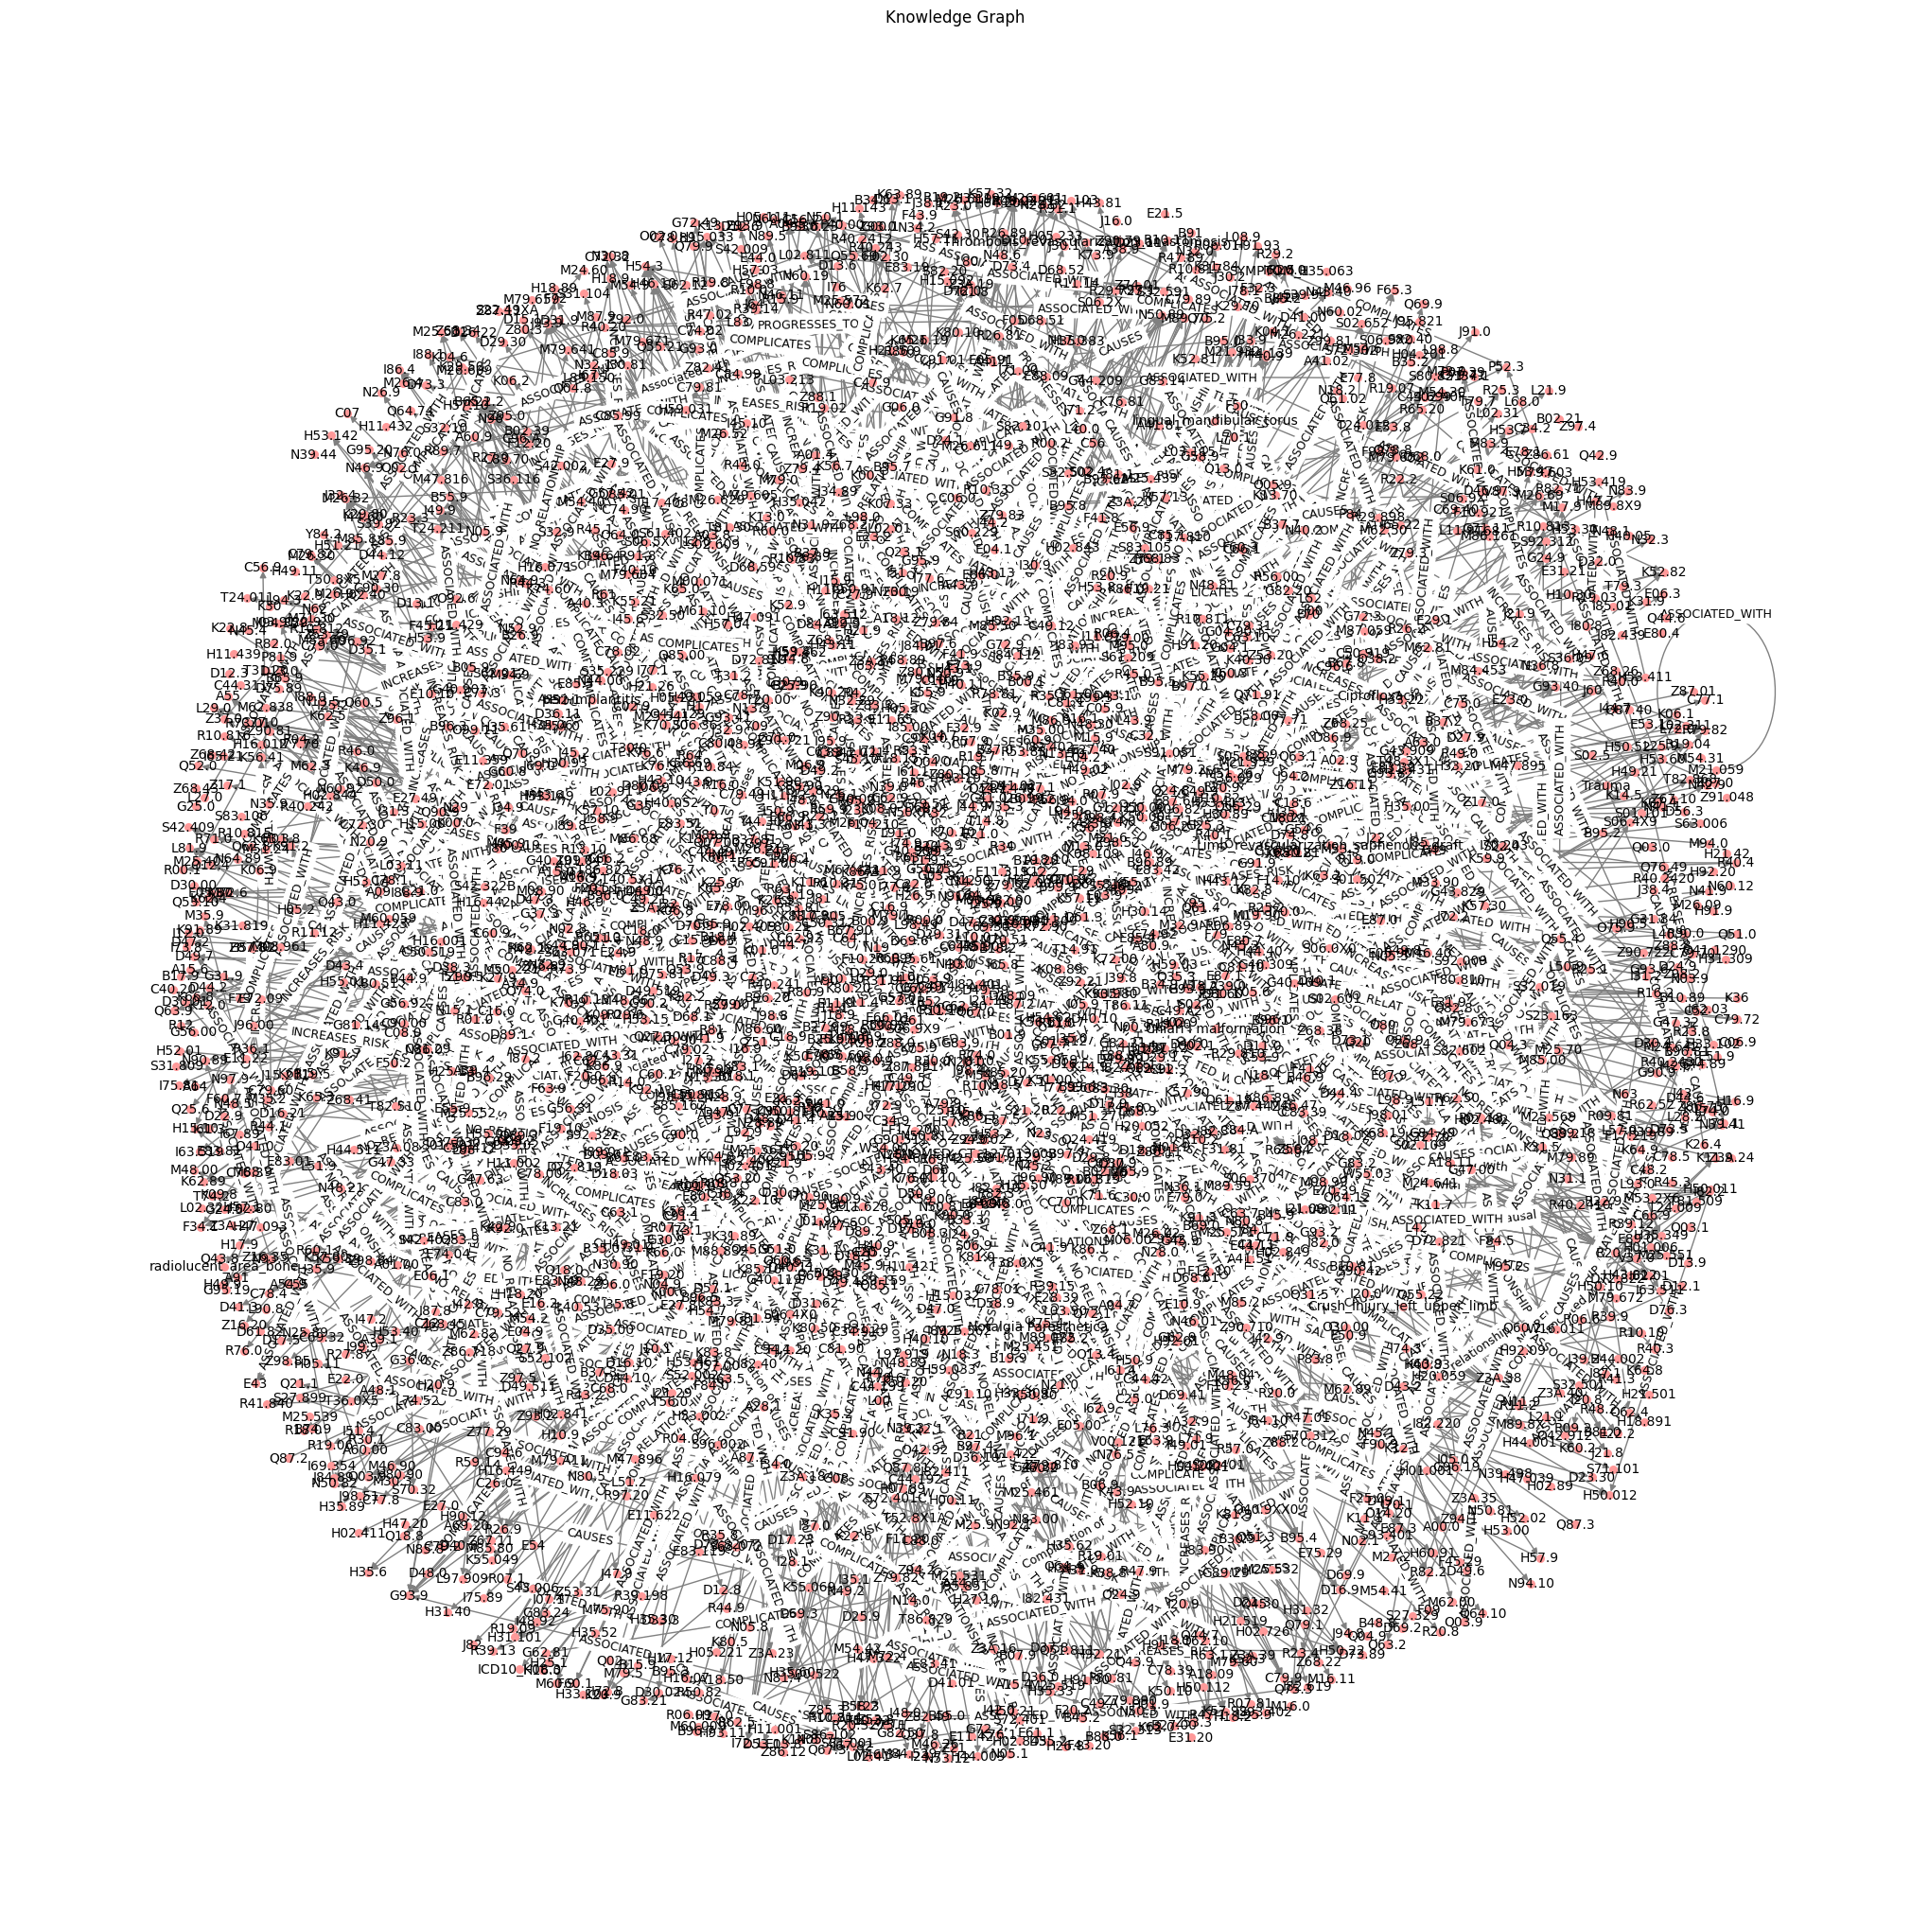

In [7]:
# Create a directed graph
G = nx.DiGraph()

# Add nodes
for node in data["nodes"]:
    G.add_node(node["id"], label=node["name"], type=node["type"], node_size=10)

# Add edges
for edge in data["edges"]:
    if G.has_node(edge["source"]) and G.has_node(edge["target"]):    
        G.add_edge(edge["source"], edge["target"], 
                   relationship=edge["relationship"], 
                   confidence=edge["confidence"],
                   text=edge["supporting_text"])

# Draw the Graph
plt.figure(figsize=(20, 20))
pos = nx.spring_layout(G, seed=42, k=0.2)  # Layout for visualization
labels = nx.get_edge_attributes(G, 'relationship')

nx.draw(G, pos, with_labels=True, node_color="#FF9999", edge_color="gray", node_size=30, font_size=10)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=9)

# Remove axis for a clean plot
plt.axis("off")

# Show plot
plt.title("Knowledge Graph")
plt.show()

In [8]:
from pyvis.network import Network

# Create a Pyvis network
net = Network(notebook=True, height="1000px", width="100%", directed=True)

# Add nodes
for node in data["nodes"]:
    lable_name = str(node["id"])+" ("+str(node["name"])+")" 
    net.add_node(node["id"], label=lable_name, title=node["type"], color="lightblue")

# Add edges
for edge in data["edges"]:
    if edge["source"] in net.node_ids and edge["target"]  in net.node_ids:
        net.add_edge(edge["source"], edge["target"], title=edge["relationship"] + " (" + edge["confidence"] + ")")        

# Save and display
net.show("knowledge_graph.html")

knowledge_graph.html


### Show a Subgraph based on an ICD-10 Code Entered -- Will show all the edges and nodes

In [ ]:
# Create the full network
net = Network(notebook=True, height="1000px", width="100%", directed=True)

# Add nodes
node_dict = {node["id"]: node for node in data["nodes"]}  # Dictionary for quick lookup
for node in data["nodes"]:
    label_name = f'{node["id"]} ({node["name"]})'
    net.add_node(node["id"], label=label_name, title=node["type"], color="lightblue")

# Add edges
edges_list = []
for edge in data["edges"]:
    if edge["source"] in node_dict and edge["target"] in node_dict:
        net.add_edge(
            edge["source"], edge["target"],
            title=f'{edge["relationship"]} ({str(edge["confidence"])})'
        )
        edges_list.append(edge)

# Save full graph
net.show("full_knowledge_graph.html")
print("Full knowledge graph saved as 'full_knowledge_graph.html'.")

# Continuous loop for user input
while True:
    node_input = input("\nEnter a node ID to explore its connections (or type 'exit' to quit): ").strip()
    
    if node_input.lower() == "exit":
        print("Exiting program.")
        break  # Exit the loop

    # Create a subgraph
    sub_net = Network(notebook=True, height="800px", width="80%", directed=True)
    
    if node_input in node_dict:
        # Highlight the selected node
        sub_net.add_node(node_input, label=f'{node_input} ({node_dict[node_input]["name"]})', 
                         title=node_dict[node_input]["type"], color="red")
        
        # Add directly connected nodes and edges
        for edge in edges_list:
            if edge["source"] == node_input or edge["target"] == node_input:
                other_node = edge["target"] if edge["source"] == node_input else edge["source"]
                sub_net.add_node(other_node, 
                                 label=f'{other_node} ({node_dict[other_node]["name"]})', 
                                 title=node_dict[other_node]["type"], color="lightblue")
                sub_net.add_edge(edge["source"], edge["target"], 
                                 title=f'{edge["relationship"]} ({str(edge["confidence"])})')

        # Save and display subgraph
        name = str(node_input).replace(".", "_")
        subgraph_filename = f"subgraph_{node_input}.html"
        sub_net.show(subgraph_filename)
        print(f"Subgraph saved as '{subgraph_filename}'. Open it in your browser to view.")

    else:
        print("Node ID not found! Please enter a valid node ID.")

full_knowledge_graph.html
Full knowledge graph saved as 'full_knowledge_graph.html'.



Enter a node ID to explore its connections (or type 'exit' to quit):  Q37.9


subgraph_Q37.9.html
Subgraph saved as 'subgraph_Q37.9.html'. Open it in your browser to view.
